# EDA du Jeu de Données de Fondation

Analyse exploratoire de `foundation_arrivals_full.parquet` — le jeu de données d'arrivées aux arrêts
reconstruit par `02_preprocessing.ipynb`.

In [1]:
from pathlib import Path
import sys
sys.path.append(str(Path.cwd().parent))

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

FA_PATH = Path("../data/processed/foundation_arrivals_full.parquet")
if FA_PATH.exists():
    fa = pd.read_parquet(FA_PATH)
    print(f"Loaded: {FA_PATH.name}  |  {len(fa):,} rows x {fa.shape[1]} columns")
else:
    fa = pd.DataFrame()
    print("Foundation not found — run: python -m src.data.build_foundation")

Loaded: foundation_arrivals_full.parquet  |  168,481 rows x 17 columns


In [3]:
# High-level counts — one number per key metric
if len(fa):
    n_trips=fa.groupby(["day","line","bus","trip_id"]).ngroups
    n_busdays=fa.groupby(["day","line","bus"]).ngroups
    n_full=fa.groupby(["day","line","bus","trip_id"])["full"].first().sum()
    print(f"Total rows (stop arrivals):{len(fa):>10,}")
    print(f"Unique bus-days: {n_busdays:>10,}")
    print(f"Unique trips: {n_trips:>10,}")
    print(f"  Full trips (end-to-end): {n_full:>10,}  ({n_full/n_trips*100:.1f}%)")
    print(f"  Partial trips: {n_trips-n_full:>10,}  ({(n_trips-n_full)/n_trips*100:.1f}%)")
    print(f"Unique bus lines: {fa['line'].nunique():>10,}")
    print(f"Unique bus vehicles: {fa['bus'].nunique():>10,}")
    print(f"Unique companies: {fa['societe'].nunique():>10,}")
    print(f"Date range:  {fa['day'].min()} to {fa['day'].max()}")
    print(f"Overall stop match rate: {fa['matched'].mean()*100:>9.1f}%")

Total rows (stop arrivals):   168,481
Unique bus-days:      3,343
Unique trips:     20,743
  Full trips (end-to-end):     17,341  (83.6%)
  Partial trips:      3,402  (16.4%)
Unique bus lines:         29
Unique bus vehicles:         35
Unique companies:          3
Date range:  20250101 to 20260621
Overall stop match rate:      76.5%


In [4]:
# Column dtypes + sample rows
if len(fa):
    print("Columns and dtypes:")
    print(fa.dtypes.to_string())
    print("\nFirst 5 rows:")
    display(fa.head())

Columns and dtypes:
day                   object
line                  object
societe               object
bus                    int64
trip_id                int64
dir                   object
full                    bool
trip_start    datetime64[ns]
trip_end      datetime64[ns]
seq                    int64
route_seq              int64
stop                  object
arrival       datetime64[ns]
departure     datetime64[ns]
dwell_s              float64
dist_m               float64
matched                 bool

First 5 rows:


,day,line,societe,bus,trip_id,dir,full,trip_start,trip_end,seq,route_seq,stop,arrival,departure,dwell_s,dist_m,matched
0,20250101,217,S.R.T.K,6036,0,ALLER,True,2025-01-01 03:00:52.299,2025-01-01 07:51:24.201,0,0,KASSERINE,2025-01-01 03:01:22.300,2025-01-01 03:04:52.262,210.0,92.0,True
1,20250101,217,S.R.T.K,6036,0,ALLER,True,2025-01-01 03:00:52.299,2025-01-01 07:51:24.201,1,1,BOUZGUEM,2025-01-01 03:14:07.268,2025-01-01 03:14:37.281,30.0,46.0,True
2,20250101,217,S.R.T.K,6036,0,ALLER,True,2025-01-01 03:00:52.299,2025-01-01 07:51:24.201,2,2,EL GARRAA,NaT,NaT,NaN,1238.0,False
3,20250101,217,S.R.T.K,6036,0,ALLER,True,2025-01-01 03:00:52.299,2025-01-01 07:51:24.201,3,3,CHRAYA,2025-01-01 03:24:01.335,2025-01-01 03:24:01.335,0.0,17.0,True
4,20250101,217,S.R.T.K,6036,0,ALLER,True,2025-01-01 03:00:52.299,2025-01-01 07:51:24.201,4,4,SBEITLA,2025-01-01 03:39:24.278,2025-01-01 03:39:24.278,0.0,118.0,True


In [5]:
# Missing values (unmatched stops have NaN arrival/departure/dwell)
if len(fa):
    missing = (fa.isnull().sum() / len(fa) * 100).sort_values(ascending=False)
    print("Missing values (%) per column:")
    print(missing[missing > 0].to_string())
    print("\n  NaN arrival/departure/dwell = no GPS ping found within 350m of that stop")

Missing values (%) per column:
departure    23.503540
arrival      23.503540
dwell_s      23.503540
dist_m        0.032051

  NaN arrival/departure/dwell = no GPS ping found within 350m of that stop


In [6]:
# Descriptive statistics for numeric columns
if len(fa):
    print(fa[["dwell_s","dist_m"]].describe().round(1).to_string())
    print("\n  dwell_s = seconds the bus was parked at the stop")
    print("  dist_m  = meters between the matched GPS ping and the stop coordinate")

        dwell_s    dist_m
count  128882.0  168427.0
mean      120.3    1535.5
std       329.2    8201.2
min         0.0       0.0
25%        20.0      14.0
50%        50.0      43.0
75%        95.0     215.0
max     31690.0  292460.0

  dwell_s = seconds the bus was parked at the stop
  dist_m  = meters between the matched GPS ping and the stop coordinate


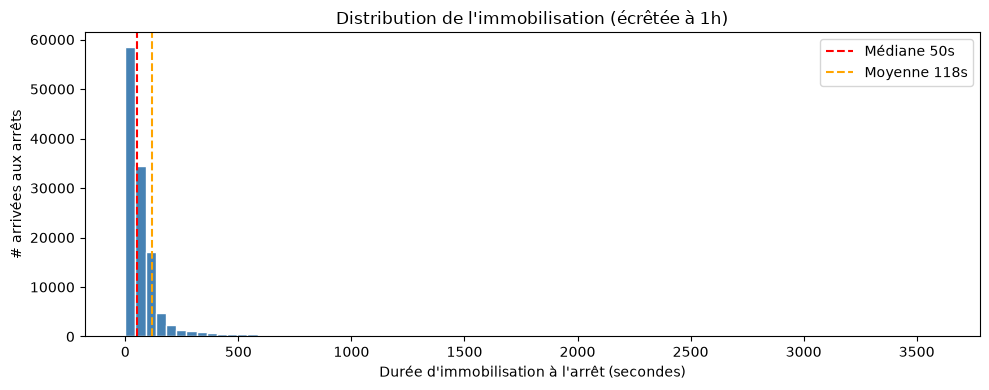

In [7]:
if len(fa):
    dwell = fa[fa["matched"]]["dwell_s"].clip(upper=3600)
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(dwell, bins=80, color="steelblue", edgecolor="white")
    ax.axvline(dwell.median(), color="red",    ls="--", label=f"Médiane {dwell.median():.0f}s")
    ax.axvline(dwell.mean(),   color="orange", ls="--", label=f"Moyenne {dwell.mean():.0f}s")
    ax.set_xlabel("Durée d'immobilisation à l'arrêt (secondes)"); ax.set_ylabel("# arrivées aux arrêts")
    ax.set_title("Distribution de l'immobilisation (écrêtée à 1h)"); ax.legend()
    plt.tight_layout(); plt.show()

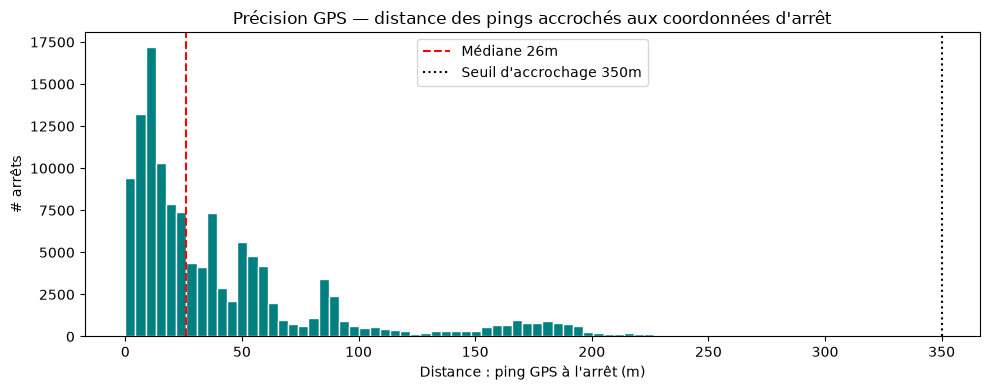

Dans les 50m : 69.1%  |  Dans les 100m : 88.2%  |  Dans les 200m : 97.6%


In [8]:
if len(fa):
    dist = fa[fa["matched"]]["dist_m"]
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(dist, bins=80, color="teal", edgecolor="white")
    ax.axvline(dist.median(), color="red",   ls="--", label=f"Médiane {dist.median():.0f}m")
    ax.axvline(350,           color="black", ls=":",  label="Seuil d'accrochage 350m")
    ax.set_xlabel("Distance : ping GPS à l'arrêt (m)"); ax.set_ylabel("# arrêts")
    ax.set_title("Précision GPS — distance des pings accrochés aux coordonnées d'arrêt")
    ax.legend(); plt.tight_layout(); plt.show()
    print(f"Dans les 50m : {(dist<=50).mean()*100:.1f}%  |  Dans les 100m : {(dist<=100).mean()*100:.1f}%  |  Dans les 200m : {(dist<=200).mean()*100:.1f}%")

### Qu'est-ce que le Taux d'Accrochage ?

Le **taux d'accrochage** est le pourcentage d'arrêts d'un trajet où un ping GPS a été trouvé dans un rayon de **350 mètres** des coordonnées de l'arrêt.

```
Exemple de trajet — Ligne 209, KASSERINE → SFAX (22 arrêts) :

  Arrêt 0  KASSERINE    → Ping GPS trouvé à 39 m          ✓ accroché
  Arrêt 1  BOUZGUEM     → Ping GPS trouvé à 6 m           ✓ accroché
  Arrêt 2  EL GARRAA    → Ping GPS trouvé à 136 m         ✓ accroché
  Arrêt 5  OUED ELMIOU  → Ping le plus proche à 2 927 m   ✗ NON accroché
  Arrêt 10 EL FAIDH     → Ping le plus proche à 8 304 m   ✗ NON accroché
  ...
  Arrêt 21 SFAX         → Ping GPS trouvé à 101 m         ✓ accroché

  Résultat : 13 accrochés / 22 total = 59 % de taux d'accrochage
```

**Pourquoi un arrêt est-il non accroché ?**
1. **Mauvaises coordonnées d'arrêt** — le lat/lon en base de données est incorrect (le plus courant)
2. **Écart de signal GPS** — le bus est passé sans envoyer de ping
3. **Bus a sauté l'arrêt** — rare mais possible

**Que révèle le taux d'accrochage ?**
- **Taux élevé (>85 %)** : coordonnées d'arrêts précises, bonne couverture GPS
- **Taux faible (<60 %)** : les coordonnées d'arrêts de cette ligne nécessitent correction
- **76 % global** : on accroche 3 arrêts sur 4 sur toutes les lignes

Le taux d'accrochage est le **signal principal de qualité des données** — il indique quelles lignes nécessitent que leurs coordonnées d'arrêts soient corrigées avant de pouvoir être utilisées pour la prédiction de retard.

bus_days  trips  stops  match_rate
societe line                                    
S.R.T.K 501          2      1      3       100.0
S.T.S   107          1      4     34       100.0
        225          3      2     73        98.6
S.R.T.K 306        144      4   1054        94.6
S.T.S   216          7      3     33        87.9
        301         28      6    850        86.8
S.R.T.K 211          5      3     87        85.1
S.T.S   306         52      2   2538        84.5
S.R.T.K 415          4      2     31        83.9
TCV     3          405     23  85412        82.6
S.T.S   226         19      4    725        81.9
S.R.T.K 202        115      3   4749        80.5
S.T.S   211         37     10   1251        79.0
S.R.T.K 500         10      3    108        78.7
        428          6      2     42        78.6
S.T.S   101        145     24   6582        76.8
        219         62     23  11732        75.2
S.R.T.K 209        127      3   4922        74.2
S.T.S   304        226      4  10506        71.0
        541          2      7    122        70.5
S.R.T.K 217        153      4   7699        70.1
        216         30      2   1413        68.5
        204        116      3   3811        68.2
        203        147      3   5513        67.7
S.T.S   215          8      4     94        63.8
S.R.T.K 205         13      2    129        61.2
        215        148      3   6207        61.0
        311          5      2     50        60.0
        212        280      4  12552        55.1
        201          6      2    140        48.6
        402          1      1      5        40.0
S.T.S   515          1      1      9        11.1
S.R.T.K 424          1      1      1         0.0
S.T.S   212          1      1      4         0.0

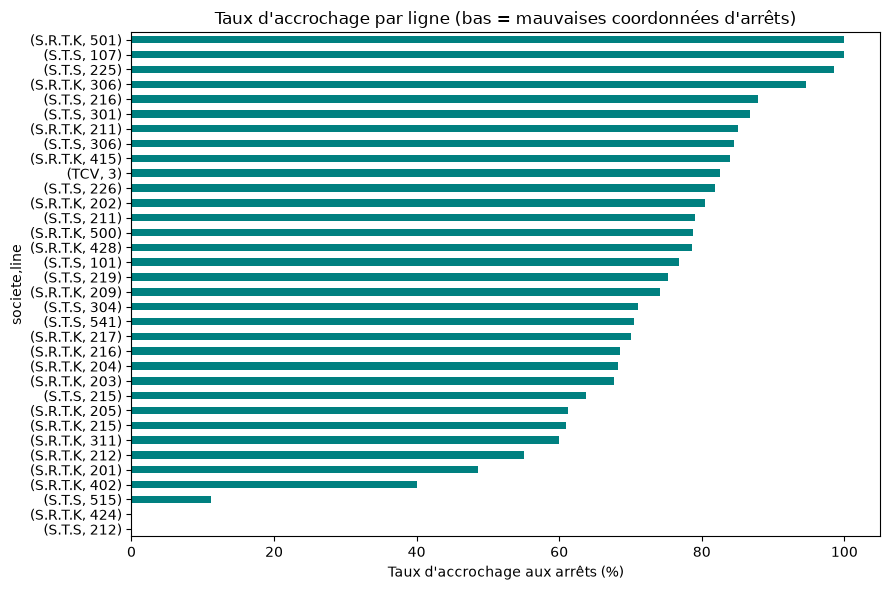

In [9]:
if len(fa):
    per_line = (fa.groupby(["societe","line"])
                  .agg(bus_days=("day","nunique"), trips=("trip_id","nunique"),
                       stops=("matched","size"), match_rate=("matched","mean"))
                  .assign(match_rate=lambda d: (d["match_rate"]*100).round(1))
                  .sort_values("match_rate", ascending=False))
    display(per_line)
    per_line["match_rate"].sort_values().plot(kind="barh", figsize=(9, 6), color="teal")
    plt.xlabel("Taux d'accrochage aux arrêts (%)"); plt.title("Taux d'accrochage par ligne (bas = mauvaises coordonnées d'arrêts)")
    plt.tight_layout(); plt.show()

In [10]:
# Data volume and match rate by company
if len(fa):
    by_company = (fa.groupby("societe")
                    .agg(rows=("day","size"), lines=("line","nunique"),
                         buses=("bus","nunique"), days=("day","nunique"),
                         match_rate=("matched","mean"))
                    .assign(match_rate=lambda d: (d["match_rate"]*100).round(1))
                    .sort_values("rows", ascending=False))
    print("Data volume and match rate by company:")
    display(by_company)

Data volume and match rate by company:


,rows,lines,buses,days,match_rate
societe,,,,,
TCV,85412,1,11,405,82.6
S.R.T.K,48516,19,19,459,66.5
S.T.S,34553,14,5,381,75.5


In [11]:
# Direction coverage: ALLER (outbound) vs RETOUR (return)
if len(fa):
    by_dir = (fa.groupby("dir")
                .agg(rows=("day","size"), trips=("trip_id","nunique"),
                     match_rate=("matched","mean"))
                .assign(match_rate=lambda d: (d["match_rate"]*100).round(1)))
    print("Coverage by direction (ALLER=outbound, RETOUR=return):")
    print(by_dir.to_string())

Coverage by direction (ALLER=outbound, RETOUR=return):
         rows  trips  match_rate
dir                             
ALLER   84382     23        80.5
RETOUR  84099     24        72.5


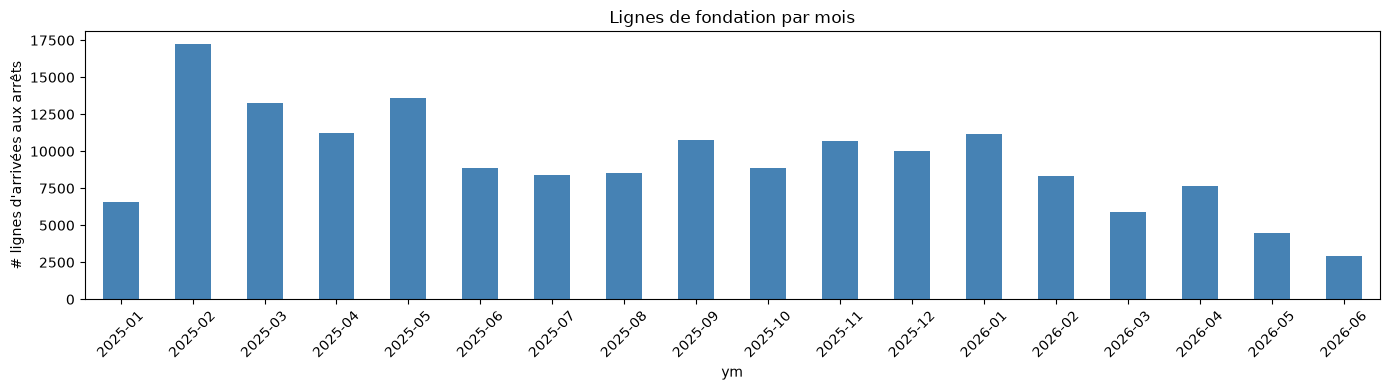

          rows  days  trips  match_rate
ym                                     
2025-01   6599    24     23        78.1
2025-02  17240    28     23        81.5
2025-03  13248    31     18        76.2
2025-04  11216    30     22        78.9
2025-05  13609    31     23        80.2
2025-06   8896    29     22        80.6
2025-07   8405    31     22        80.9
2025-08   8506    30     23        79.1
2025-09  10791    30     23        73.1
2025-10   8871    31     23        71.3
2025-11  10665    30     24        75.1
2025-12   9990    31     22        79.2
2026-01  11185    31     22        74.5
2026-02   8335    28     22        72.5
2026-03   5897    29     20        72.2
2026-04   7675    30     20        68.8
2026-05   4445    26     20        68.4
2026-06   2908    21     21        70.2


In [12]:
if len(fa):
    tmp = fa.copy()
    tmp["ym"] = pd.to_datetime(tmp["day"], format="%Y%m%d").dt.to_period("M")
    by_month = (tmp.groupby("ym")
                   .agg(rows=("day","size"), days=("day","nunique"),
                        trips=("trip_id","nunique"), match_rate=("matched","mean"))
                   .assign(match_rate=lambda d: (d["match_rate"]*100).round(1)))
    by_month["rows"].plot(kind="bar", figsize=(14, 4), color="steelblue")
    plt.ylabel("# lignes d'arrivées aux arrêts"); plt.title("Lignes de fondation par mois")
    plt.xticks(rotation=45); plt.tight_layout(); plt.show()
    print(by_month.to_string())

### Analyse du volume mensuel — résultats clés

**Lignes par jour** (lignes ÷ jours) est plus informatif que le nombre brut de lignes car les mois ont des longueurs différentes :

```
2025-01 :   275 lignes/jour   ← faible base de référence
2025-02 :   616 lignes/jour   ← pic soudain (quelque chose a été ajouté)
2025-03 :   427 lignes/jour
2025-05 :   439 lignes/jour
2025-09 :   360 lignes/jour   ← déclin progressif commence
2026-01 :   361 lignes/jour
2026-04 :   256 lignes/jour
2026-05 :   171 lignes/jour
2026-06 :   138 lignes/jour   ← mois partiel (données jusqu'au 21 juin)
```

**⚠️ La colonne `trips` est trompeuse** — `trip_id` se réinitialise à 0, 1, 2... par bus-jour, donc
`nunique()` sur un mois donne le maximum de trajets que n'importe quel bus a effectués dans une journée (~3), pas
le total de trajets du mois. À ignorer.

---

#### Ce qui explique les tendances ?

**Pic de fév. 2025 (275 → 616 lignes/jour)**
Un saut soudain de 2,2× en un seul mois indique l'installation de nouveaux traceurs GPS ou la mise en service d'une nouvelle flotte de compagnie — pas une croissance progressive. Quelque chose a été ajouté.

**Déclin 2026 (360 → 138 lignes/jour)**
L'explication la plus probable est la **mise hors service de traceurs GPS** (cassés, retirés, ou non remplacés). Avec seulement 35 véhicules de bus uniques dans tout le jeu de données, même 3–4 traceurs qui s'éteignent réduit significativement le volume. Autres causes possibles :
- Bus mis hors service
- Compagnies réduisant leurs opérations
- Script de construction de la fondation pas encore exécuté sur les jours les plus récents

**Taux d'accrochage en baisse (81,5 % → 68,4 %)**
C'est une tendance séparée de la baisse de volume. Causes possibles :
- Différentes lignes devenant actives en 2026 avec de moins bonnes coordonnées d'arrêts
- Dérive du schéma GPS — on a déjà trouvé que `direction` est passé à 98 % nul en 2026 ; si la précision de position a aussi dégradé, les pings atterrissent plus loin des arrêts
- Moins de bus par ligne signifie moins de pings redondants près de chaque arrêt, rendant les ratés plus probables

**Vérification :** croiser `fa.groupby('ym')['bus'].nunique()` — si le nombre d'identifiants de bus uniques baisse en 2026, la mise hors service des traceurs GPS est confirmée.

         active_buses   rows  rows_per_day
ym                                        
2025-01            10   6599         275.0
2025-02            18  17240         616.0
2025-03            15  13248         427.0
2025-04            13  11216         374.0
2025-05            15  13609         439.0
2025-06            14   8896         307.0
2025-07            15   8405         271.0
2025-08            15   8506         284.0
2025-09            19  10791         360.0
2025-10            16   8871         286.0
2025-11            22  10665         356.0
2025-12            20   9990         322.0
2026-01            18  11185         361.0
2026-02            16   8335         298.0
2026-03            17   5897         203.0
2026-04            17   7675         256.0
2026-05            13   4445         171.0
2026-06            17   2908         138.0


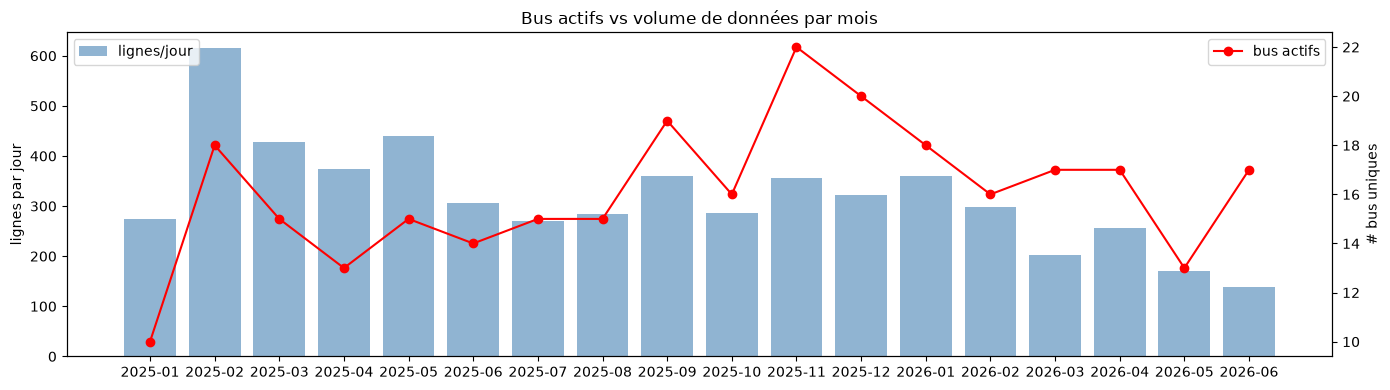

In [13]:
if len(fa):
    tmp = fa.copy()
    tmp["ym"] = pd.to_datetime(tmp["day"], format="%Y%m%d").dt.to_period("M")
    by_month_bus = tmp.groupby("ym").agg(
        active_buses=("bus", "nunique"),
        rows=("day", "size"),
        rows_per_day=("day", lambda x: len(x) / x.nunique())
    ).round(0)
    print(by_month_bus.to_string())

    fig, ax1 = plt.subplots(figsize=(14, 4))
    ax2 = ax1.twinx()
    ax1.bar(by_month_bus.index.astype(str), by_month_bus["rows_per_day"], color="steelblue", alpha=0.6, label="lignes/jour")
    ax2.plot(by_month_bus.index.astype(str), by_month_bus["active_buses"], color="red", marker="o", label="bus actifs")
    ax1.set_ylabel("lignes par jour"); ax2.set_ylabel("# bus uniques")
    ax1.set_title("Bus actifs vs volume de données par mois")
    plt.xticks(rotation=45)
    ax1.legend(loc="upper left"); ax2.legend(loc="upper right")
    plt.tight_layout(); plt.show()

In [14]:
# Tableau de bord qualité du jeu de données de fondation
if len(fa):
    n_trips   = fa.groupby(["day","line","bus","trip_id"]).ngroups
    n_busdays = fa.groupby(["day","line","bus"]).ngroups
    n_full    = fa.groupby(["day","line","bus","trip_id"])["full"].first().sum()
    match_pct = fa["matched"].mean() * 100
    def grade(v, lo, hi): return "EXCELLENT" if v >= hi else "BON" if v >= lo else "À AMÉLIORER"
    print("=" * 55)
    print("JEU DE DONNÉES DE FONDATION  —  TABLEAU DE BORD QUALITÉ")
    print("=" * 55)
    print(f"  Lignes (arrivées aux arrêts) : {len(fa):,}")
    print(f"  Jours-bus                    : {n_busdays:,}")
    print(f"  Trajets                      : {n_trips:,}")
    print(f"  Lignes                       : {fa['line'].nunique()}")
    print(f"  Compagnies                   : {fa['societe'].nunique()}")
    print(f"  Plage de dates               : {fa['day'].min()} -> {fa['day'].max()}")
    print(f"  Taux d'accrochage            : {match_pct:.1f}%  [{grade(match_pct, 65, 85)}]")
    print(f"  Taux de trajets complets     : {n_full/n_trips*100:.1f}%")
    print("=" * 55)

JEU DE DONNÉES DE FONDATION  —  TABLEAU DE BORD QUALITÉ
  Lignes (arrivées aux arrêts) : 168,481
  Jours-bus                    : 3,343
  Trajets                      : 20,743
  Lignes                       : 29
  Compagnies                   : 3
  Plage de dates               : 20250101 -> 20260621
  Taux d'accrochage            : 76.5%  [BON]
  Taux de trajets complets     : 83.6%
